In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
sns.set_palette("Set2")

In [4]:
df=pd.read_csv('customer_shopping_data.csv')

In [11]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,year,month,year_month,revenue
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,2022,8,2022-08,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,2021,12,2021-12,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,2021,11,2021-11,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,2021,5,2021-05,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,2021,10,2021-10,242.40


In [12]:
print(df.info())
print('\n')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
 10  year            99457 non-null  int32         
 11  month           99457 non-null  int32         
 12  year_month      99457 non-null  period[M]     
 13  revenue         99457 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(2), int64(2), 

In [9]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d/%m/%Y')
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month
df['year_month'] = df['invoice_date'].dt.to_period('M')
df['revenue'] = df['price'] * df['quantity']

In [13]:
print("\n===== TOTAL REVENUE BY CATEGORY =====")
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
print(category_revenue)

print("\n===== AVERAGE PURCHASE BY CATEGORY =====")
avg_purchase = df.groupby('category')['revenue'].mean().sort_values(ascending=False)
print(avg_purchase)


===== TOTAL REVENUE BY CATEGORY =====
category
Clothing           1.139968e+08
Shoes              6.655345e+07
Technology         5.786235e+07
Cosmetics          6.792863e+06
Toys               3.980426e+06
Food & Beverage    8.495351e+05
Books              8.345529e+05
Souvenir           6.358247e+05
Name: revenue, dtype: float64

===== AVERAGE PURCHASE BY CATEGORY =====
category
Technology         11581.735388
Shoes               6632.793649
Clothing            3305.500364
Cosmetics            449.947864
Toys                 394.609521
Books                167.547260
Souvenir             127.190368
Food & Beverage       57.494251
Name: revenue, dtype: float64


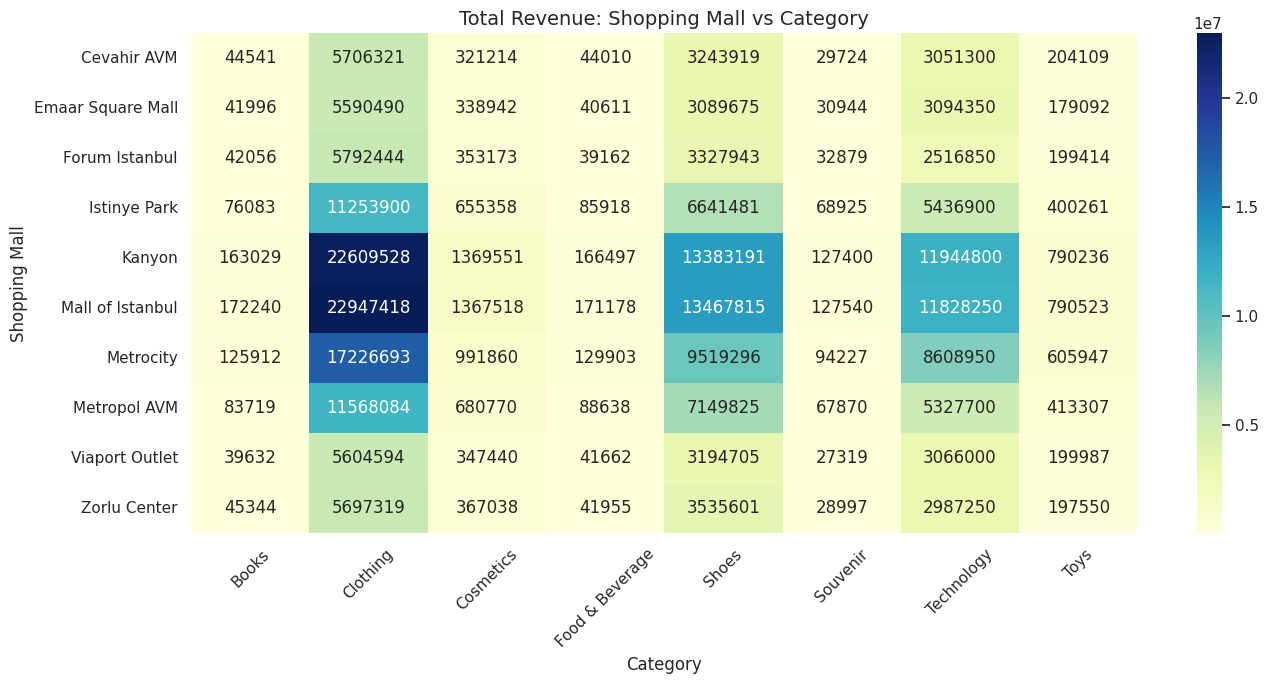

In [14]:
pivot_table = pd.pivot_table(
    df,
    values='revenue',
    index='shopping_mall',
    columns='category',
    aggfunc='sum'
)
plt.figure(figsize=(14,7))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt=".0f")
plt.title('Total Revenue: Shopping Mall vs Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Shopping Mall')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

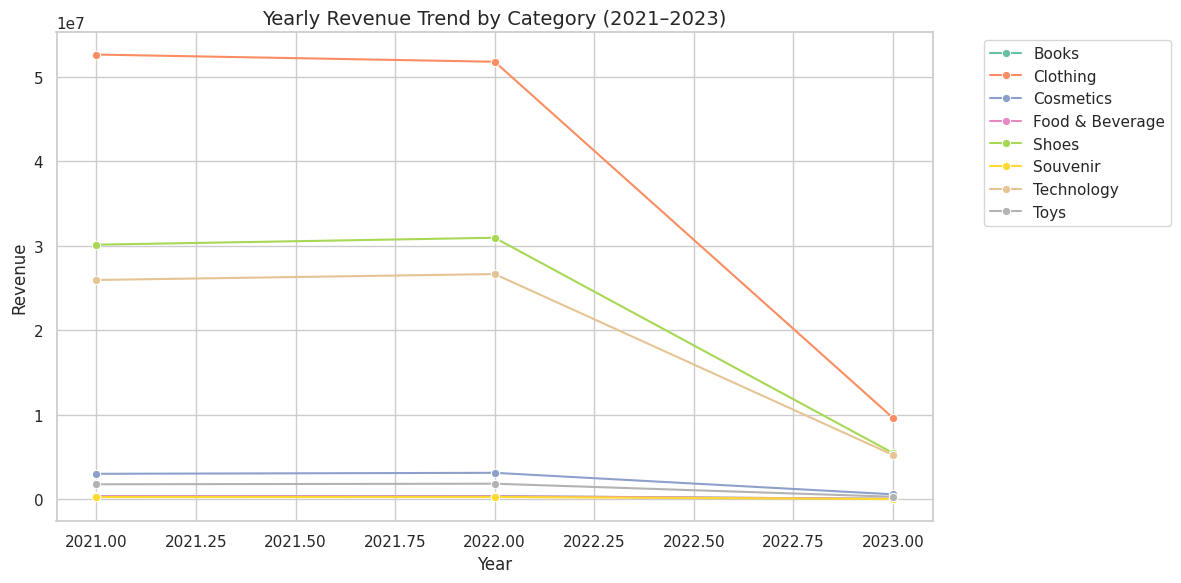

In [15]:
yearly_trend = df.groupby(['year','category'])['revenue'].sum().reset_index()
yearly_trend = yearly_trend[yearly_trend['year'].isin([2021, 2022, 2023])]
plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_trend, x='year', y='revenue', hue='category', marker='o')
plt.title('Yearly Revenue Trend by Category (2021–2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

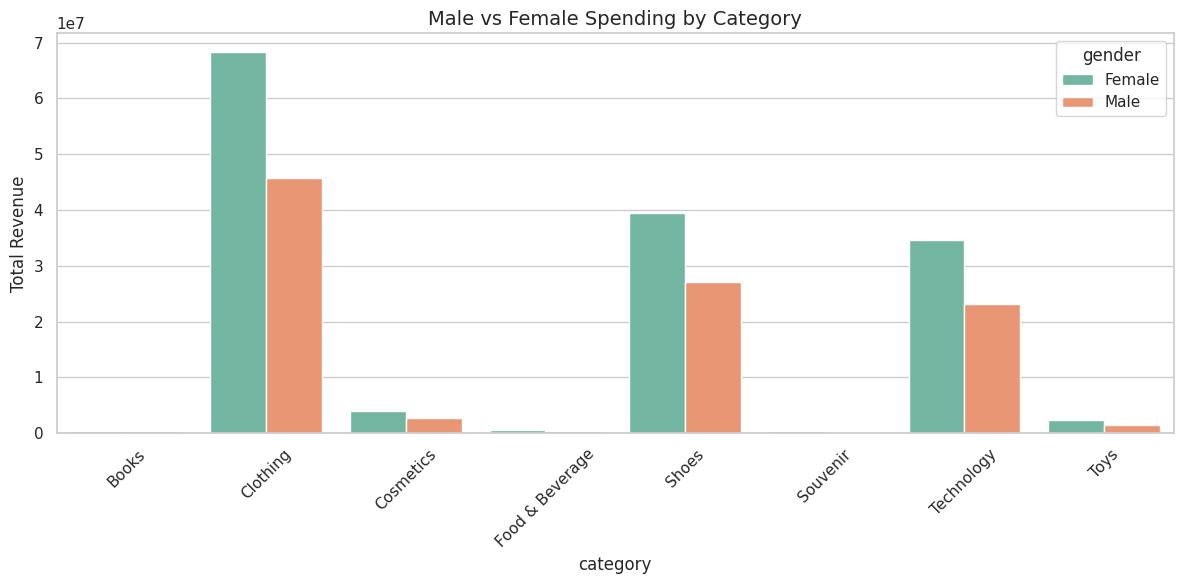

In [16]:
gender_analysis = df.groupby(['category','gender'])['revenue'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=gender_analysis, x='category', y='revenue', hue='gender')
plt.title('Male vs Female Spending by Category', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

In [22]:
payment = df.groupby(['category','payment_method']).size().reset_index(name='count')
dominant_payment = payment.loc[payment.groupby('category')['count'].idxmax()]

print("\n===== DOMINANT PAYMENT METHOD PER CATEGORY =====\n")
print(dominant_payment)


===== DOMINANT PAYMENT METHOD PER CATEGORY =====

           category payment_method  count
0             Books           Cash   2268
3          Clothing           Cash  15456
6         Cosmetics           Cash   6674
9   Food & Beverage           Cash   6587
12            Shoes           Cash   4474
15         Souvenir           Cash   2211
18       Technology           Cash   2235
21             Toys           Cash   4542


In [28]:
monthly_avm = df.groupby(['shopping_mall','year_month'])['revenue'].sum().reset_index()
monthly_avm['growth_rate_%'] = monthly_avm.groupby('shopping_mall')['revenue'].pct_change() * 100
print("\n=====        MONTHLY GROWTH RATE PER AVM       =====\n")
print(monthly_avm.dropna().head(10))


=====        MONTHLY GROWTH RATE PER AVM       =====

   shopping_mall year_month    revenue  growth_rate_%
1    Cevahir AVM    2021-02  329264.45     -31.946260
2    Cevahir AVM    2021-03  512891.12      55.768751
3    Cevahir AVM    2021-04  432312.84     -15.710602
4    Cevahir AVM    2021-05  489344.99      13.192333
5    Cevahir AVM    2021-06  400583.19     -18.138900
6    Cevahir AVM    2021-07  547457.71      36.665173
7    Cevahir AVM    2021-08  423705.15     -22.604953
8    Cevahir AVM    2021-09  488999.18      15.410252
9    Cevahir AVM    2021-10  537142.92       9.845362
10   Cevahir AVM    2021-11  586604.80       9.208328


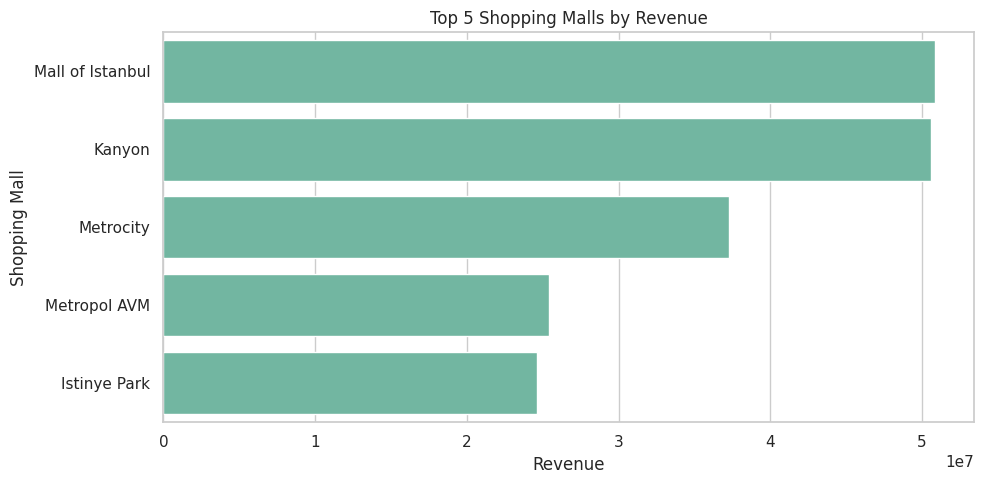

In [29]:
top_avm = df.groupby('shopping_mall')['revenue'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,5))
sns.barplot(x=top_avm.values, y=top_avm.index)
plt.title('Top 5 Shopping Malls by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Shopping Mall')
plt.tight_layout()
plt.show()
